# FP&A Automation Engine — Financial Analysis
This notebook demonstrates how raw financial data is transformed into:
- Profitability analysis
- Cost structure insights
- Forecasting outputs
- Automated financial insights

In [6]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [7]:
# Make plots look clean
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [9]:
#load data
df = pd.read_csv('../data/financials.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()

,Date,Revenue,Headcount,Salary Cost,Marketing,Other Costs
0,2024-01-01,102000,10,50000,18360,10200
1,2024-02-01,105060,10,50000,18910,10506
2,2024-03-01,109262,10,50000,19667,10926
3,2024-04-01,111447,10,50000,20060,11144
4,2024-05-01,114790,10,50000,20662,11479


In [10]:
#core Calculations
df['Total Costs'] = df['Salary Cost'] + df['Marketing'] + df['Other Costs']
df['Profit'] = df['Revenue'] - df['Total Costs']
df['Profit Margin'] = df['Profit'] / df['Revenue']
df['Revenue Growth %'] = df['Revenue'].pct_change()

df.tail()

,Date,Revenue,Headcount,Salary Cost,Marketing,Other Costs,Total Costs,Profit,Profit Margin,Revenue Growth %
19,2025-08-01,178746,16,80000,32174,17874,130048,48698,0.272442,0.029999
20,2025-09-01,185895,16,80000,33461,18589,132050,53845,0.289653,0.039995
21,2025-10-01,189612,16,80000,34130,18961,133091,56521,0.298088,0.019995
22,2025-11-01,195300,16,80000,35154,19530,134684,60616,0.310374,0.029998
23,2025-12-01,203112,16,80000,36560,20311,136871,66241,0.326130,0.040000


Visualization #1 (Revenue vs Costs)

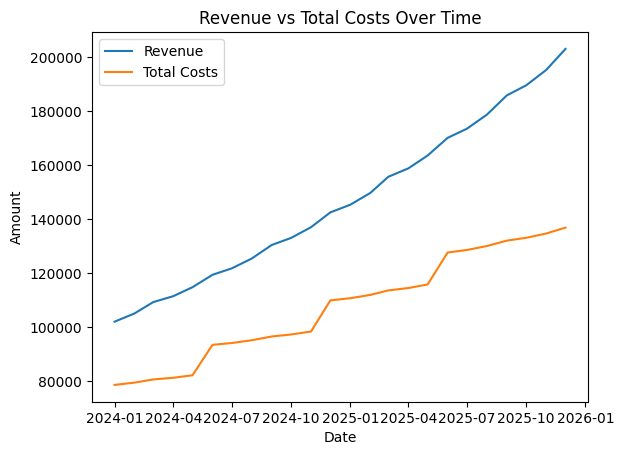

In [13]:
plt.figure()

plt.plot(df['Date'], df['Revenue'],label='Revenue')
plt.plot(df['Date'], df['Total Costs'],label='Total Costs')

plt.title("Revenue vs Total Costs Over Time")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.show()

### Insight
This chart shows how revenue and cost structure evolve over time.
Key observations:
- Whether costs are scaling faster than revenue
- If profitability is improving or deteriorating

Visualization #2 (Profit Margin)

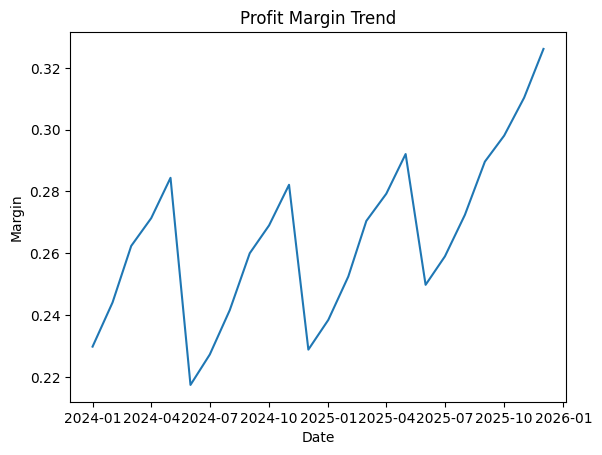

In [14]:
plt.figure()

plt.plot(df['Date'], df['Profit Margin'])

plt.title("Profit Margin Trend")
plt.xlabel("Date")
plt.ylabel("Margin")

plt.show()

In [16]:
#Forecast Function
def forecast_next_periods(df, periods=3):
    last_row = df.iloc[-1]
    forecast_rows = []

    for i in range(periods):
        new_row = last_row.copy()

        new_row['Revenue'] *= 1.05
        new_row['Salary Cost'] *= 1.02
        new_row['Marketing'] *= 1.03

        new_row['Total Costs'] = new_row['Salary Cost'] + new_row['Marketing'] + new_row['Other Costs']
        new_row['Profit'] = new_row['Revenue'] - new_row['Total Costs']
        new_row['Profit Margin'] = new_row['Profit'] / new_row['Revenue']

        forecast_rows.append(new_row)
        last_row = new_row

    return pd.DataFrame(forecast_rows)

forecast_df = forecast_next_periods(df)
forecast_df

,Date,Revenue,Headcount,Salary Cost,Marketing,Other Costs,Total Costs,Profit,Profit Margin,Revenue Growth %
23,2025-12-01,213267.600,16,81600.00,37656.80000,20311,139567.80000,73699.80000,0.345574,0.04
23,2025-12-01,223930.980,16,83232.00,38786.50400,20311,142329.50400,81601.47600,0.364405,0.04
23,2025-12-01,235127.529,16,84896.64,39950.09912,20311,145157.73912,89969.78988,0.382643,0.04


In [17]:
#Combine Actuals + Forecast
combined = pd.concat([df, forecast_df])
combined.reset_index(drop=True, inplace=True)

combined.tail()

,Date,Revenue,Headcount,Salary Cost,Marketing,Other Costs,Total Costs,Profit,Profit Margin,Revenue Growth %
22,2025-11-01,195300.000,16,80000.00,35154.00000,19530,134684.00000,60616.00000,0.310374,0.029998
23,2025-12-01,203112.000,16,80000.00,36560.00000,20311,136871.00000,66241.00000,0.326130,0.040000
24,2025-12-01,213267.600,16,81600.00,37656.80000,20311,139567.80000,73699.80000,0.345574,0.040000
25,2025-12-01,223930.980,16,83232.00,38786.50400,20311,142329.50400,81601.47600,0.364405,0.040000
26,2025-12-01,235127.529,16,84896.64,39950.09912,20311,145157.73912,89969.78988,0.382643,0.040000


Visualization #3 (Forecast View)

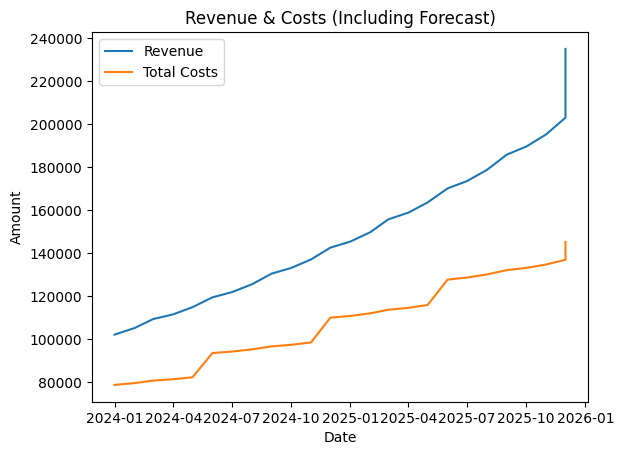

In [18]:
plt.figure()

plt.plot(combined['Date'], combined['Revenue'],label='Revenue')
plt.plot(combined['Date'], combined['Total Costs'],label='Total Costs')

plt.title("Revenue & Costs (Including Forecast)")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.show()

Insight Engine

In [23]:
def generate_insights(df):
    latest = df.iloc[-1]
    insights = []

    profit_margin = latest['Profit Margin']
    marketing_ratio = latest['Marketing'] / latest['Revenue']
    growth = latest['Revenue Growth %']

    # Profitability insight
    if profit_margin < 0.2:
        insights.append("⚠️ Profit margin below 20% - cost pressure detected")
    else:
        insights.append("✅ Profitability is healthy")

    # Marketing efficiency
    if marketing_ratio > 0.3:
        insights.append("⚠️ Marketing spend is high relative to revenue")
    else:
        insights.append("✅ Marketing spend is within reasonable range")

    # Growth insight
    if pd.notna(growth):
        if growth < 0.02:
            insights.append("⚠️ Revenue growth is slowing")
        else:
            insights.append("✅ Revenue growth is stable")

    return insights


In [24]:
generate_insights(df)

['✅ Profitability is healthy',
 '✅ Marketing spend is within reasonable range',
 '✅ Revenue growth is stable']

### Summary

This notebook demonstrates how financial data can be:
- Processed automatically
- Transformed into insights
- Extended into forecasting

This forms the foundation for a fully automated FP&A system.